# NLP — 06. Bag of Words (BoW)

Now we reach an important transition in NLP.

So far, we've worked with text:

`"I love Python"`

But a machine learning model cannot directly perform mathematical operations on the word `"Python".`

We need to convert text into **numbers.**

One of the earliest and simplest ways to do this is **Bag of Words (BoW).**

## 1. What is Bag of Words?

**Bag of Words is a technique that represents text using the words that occur in it and their frequencies.**

The word **"bag"** is important.

BoW treats a sentence as a collection, or **bag**, of words and i**gnores the order of the words.**

For example: `"I love Python"` and `"Python love I"`

would contain the same words:

```
I
love
Python
```

Therefore, a basic BoW representation treats them similarly.

## 2. A simple example

Suppose we have three sentences:

```
Sentence 1: "I love Python"
Sentence 2: "I love NLP"
Sentence 3: "Python is powerful"
```

First, create a vocabulary containing all unique words and assign each word a position:

vocab: ["I", "love", "Python", "NLP", "is", "powerful"]

index: [1, 2, 3, 4, 5, 6]

Now each word has an index and Each sentence can now be represented using numbers.

## 3. Creating the vectors

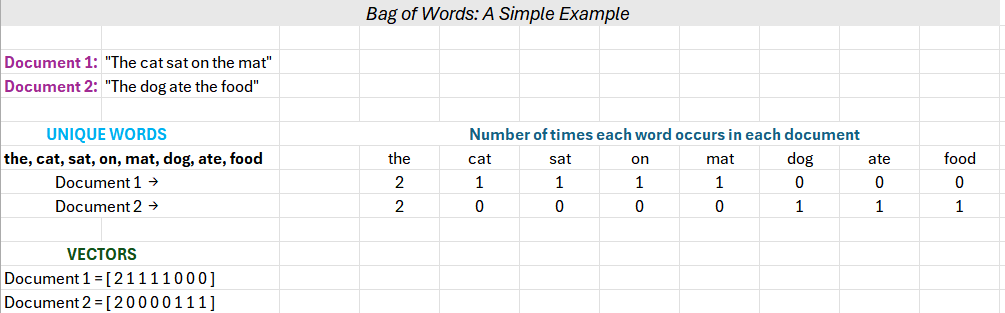

A machine learning model can work with these vectors.

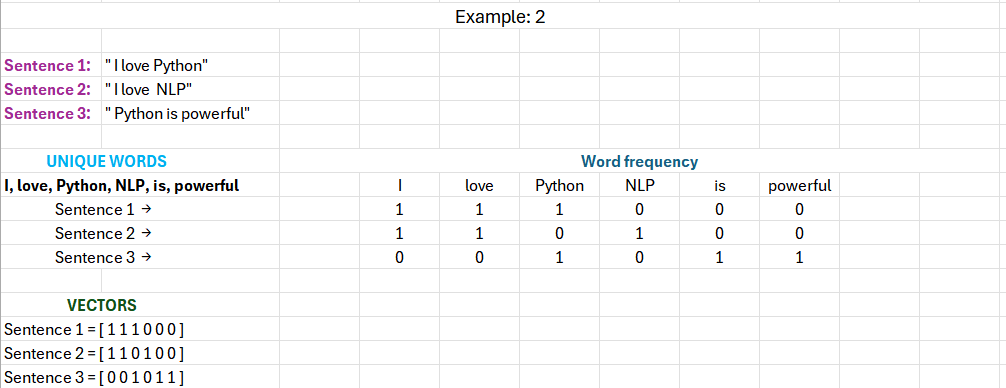

## 4. Why is it called "Bag" of Words?

Because **word order is ignored.**

Consider:

`"The dog chased the cat."`

and:

`"The cat chased the dog."`

BoW sees essentially the same collection of words:

```
the
dog
chased
cat
```

**It doesn't understand that the dog performed the action in the first sentence and the cat performed the action in the second.**

This is one of the **fundamental limitations** of BoW.

## 5. Word frequency

So far we've used:

`1 → word exists`

`0 → word doesn't exist`

But BoW can also count **how many times a word occurs.**

Consider: "Python is easy. Python is powerful."

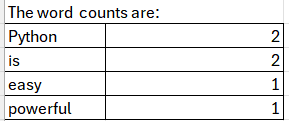

So the vector represents the **frequency** of each word.

This is called a **Count Vector** or **Count Vectorization.**

## 6. Implementing BoW manually

In [1]:
#Let's create a very small example in Python.
sentences = [
    "I love Python",
    "I love NLP",
    "Python is powerful"
]

# Create vocabulary
vocabulary = set()

for sentence in sentences:
    vocabulary.update(sentence.lower().split())

vocabulary = sorted(vocabulary)

print(vocabulary)

['i', 'is', 'love', 'nlp', 'powerful', 'python']


In [2]:
#Now create vectors:
vectors = []

for sentence in sentences:
    words = sentence.lower().split()

    vector = [
        words.count(word)
        for word in vocabulary
    ]

    vectors.append(vector)

print(vectors)

[[1, 0, 1, 0, 0, 1], [1, 0, 1, 1, 0, 0], [0, 1, 0, 0, 1, 1]]


In [ ]:
#We've just implemented a basic Bag of Words representation ourselves.

## 7. Using Scikit-learn

In [3]:
#In practice, we don't need to manually implement it.
#scikit-learn provides CountVectorizer.

from sklearn.feature_extraction.text import CountVectorizer

sentences = [
    "I love Python",
    "I love NLP",
    "Python is powerful"
]

vectorizer = CountVectorizer()

X = vectorizer.fit_transform(sentences)

In [4]:
#Let's see the vocabulary:
print(vectorizer.get_feature_names_out())

['is' 'love' 'nlp' 'powerful' 'python']


In [5]:
print(X.toarray())
#Each row represents one sentence.
#Each column represents one word in the vocabulary.

[[0 1 0 0 1]
 [0 1 1 0 0]
 [1 0 0 1 1]]


## 8. The biggest problem with BoW

BoW completely ignores **word order and context.**

Compare:

`"I love this movie"`

with:

`"I hate this movie"`

BoW can distinguish them because `love` and `hate` are different words.

But consider:

`"The dog chased the cat"`

and:

`"The cat chased the dog"`

They contain the same words.

BoW produces the same word counts.

But their meanings are different.

So BoW understands:

> **Which words are present?**

But not:

> **How are those words related?**

## 9. Another major problem: vocabulary size


Imagine we have:

`1,000,000 unique words`

Our vectors could potentially contain:

`[0, 0, 0, 0, 0, ... 1, 0, 0, ...]`

with **one million dimensions.**

Most entries would be zero.

This creates a **high-dimensional sparse representation.**

For example:

```
Vocabulary = 10,000 words

Document:
"I love Python"

Vector:
[0, 1, 0, 0, 0, 0, 1, ...]
```

Only a few positions contain useful information.

## 10. BoW doesn't understand meaning

Consider:

`"I love cars"`

and:

`"I adore automobiles"`

A human understands that these sentences are semantically similar.

BoW doesn't.

It sees:

`love ≠ adore`

`cars ≠ automobiles`

because each is treated as a separate vocabulary item.

This is a major limitation.

Later, **word embeddings** will solve this problem much better.

## 11. BoW limitations

Keep these four limitations in your notebook:

**1. Ignores word order**

`dog bites man`

`man bites dog`

can have the same representation.

**2. Doesn't understand semantics**

`car` `automobile`
are treated as unrelated words.

**3. High-dimensional**

Large vocabulary → very large vectors.

**4. Sparse representation**

Most values in the vector are usually `0`.


## 12. Why are we learning BoW if modern LLMs don't use it?


Because BoW introduces a fundamental idea:

> **Convert language into a numerical representation that a machine can process.**

The evolution then becomes:

```
Bag of Words
     ↓
TF-IDF
     ↓
Word Embeddings
     ↓
Contextual Embeddings
     ↓
Transformers
     ↓
LLMs
```

Each step attempts to solve limitations of the previous representation.

BoW asks:

> **"Which words appear, and how often?"**

TF-IDF will improve this by asking:

> **"How important is this word to this particular document?"**

That is our next topic.

# NLP — 07. TF-IDF